# Лабораторная работа №2

## Выполнил студент: Черкасов Александр Андреевич, ИВТб-2301

### Вариант 24

In [1]:
import numpy as np
import matplotlib.pyplot as plot
from IPython.display import display, Markdown

def md(s: str) -> None:
    display(Markdown(s))

## 1. Решение системы линейных уравнений 4-го порядка методом Гаусса с точностью e=0.001

### Теоретическая справка: Метод Гаусса с выбором главного элемента
Метод Гаусса — это классический прямой метод решения систем линейных алгебраических уравнений (СЛАУ). Его алгоритм делится на два основных этапа:
1. **Прямой ход (исключение переменных)**: Расширенная матрица $[A|b]$ приводится к верхнетреугольному (ступенчатому) виду. Для повышения численной устойчивости и предотвращения деления на малые значения используется **выбор главного элемента по столбцу**: на каждом шаге $i$ среди элементов $i$-го столбца (начиная с $i$-й строки) находится максимальный по модулю элемент, и соответствующая строка переставляется с текущей.
2. **Обратный ход (подстановка)**: Начиная с последнего уравнения, последовательно вычисляются значения неизвестных $x_n, x_{n-1}, \dots, x_1$.

Метод является точным, а погрешность решения определяется исключительно ошибками округления в процессе вычислений.

Уравнения системы для Варианта 24:
$$0.13x_1 + 0.22x_2 - 0.14x_3 + 0.15x_4 = 1.00$$
$$0.22x_1 - 0.31x_2 + 0.42x_3 - 5.10x_4 = 6.01$$
$$0.62x_1 - 0.74x_2 + 0.85x_3 - 0.96x_4 = 0.11$$
$$0.12x_1 + 0.31x_2 + 0.14x_3 + 0.45x_4 = 0.16$$

In [2]:
# Коэффициенты для варианта 24
A1 = np.array([
    [0.13,  0.22, -0.14,  0.15],
    [0.22, -0.31,  0.42, -5.10],
    [0.62, -0.74,  0.85, -0.96],
    [0.12,  0.31,  0.14,  0.45]
], dtype=float)
b1 = np.array([1.00, 6.01, 0.11, 0.16], dtype=float)

def gauss_method(A_in, b_in):
    A = A_in.copy()
    b = b_in.copy()
    n = len(b)
    for i in range(n):
        # Поиск главного элемента
        max_el = abs(A[i][i])
        max_row = i
        for k in range(i+1, n):
            if abs(A[k][i]) > max_el:
                max_el = abs(A[k][i])
                max_row = k
        A[[i, max_row]] = A[[max_row, i]]
        b[[i, max_row]] = b[[max_row, i]]

        # Прямой ход
        for k in range(i+1, n):
            c = -A[k][i] / A[i][i]
            for j in range(i, n):
                if i == j:
                    A[k][j] = 0
                else:
                    A[k][j] += c * A[i][j]
            b[k] += c * b[i]

    # Обратный ход
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = b[i]
        for j in range(i+1, n):
            x[i] -= A[i][j] * x[j]
        x[i] = x[i] / A[i][i]
    return x

x1 = gauss_method(A1, b1)
md("**Решение методом Гаусса для задачи 1:**")
for i, xi in enumerate(x1):
    md(f"$x_{i+1} = {xi:.3f}$")

**Решение методом Гаусса для задачи 1:**

$x_1 = 3.471$

$x_2 = 2.054$

$x_3 = -2.114$

$x_4 = -1.328$

## 2. Решение системы линейных уравнений 4-го порядка методом простой итерации с точностью e=0.0001

### Теоретическая справка: Метод простой итерации
Метод простой итерации относится к итерационным (приближенным) методам. Для его реализации исходная система $Ax = b$ приводится к виду:
$$x = Bx + c$$
Алгоритм заключается в построении последовательности векторов $x^{(k+1)} = Bx^{(k)} + c$, где $x^{(0)}$ — начальное приближение (обычно нулевой вектор или вектор $c$).

**Критерий сходимости**: Метод сходится, если какая-либо норма матрицы $B$ меньше единицы ($||B|| < 1$). В данной работе используется бесконечная норма (максимальная сумма модулей элементов строк).
**Критерий остановки**: Вычисления прекращаются, когда выполняется условие достигнутой точности $\varepsilon$:
$$||x^{(k+1)} - x^{(k)}||_\infty \le \varepsilon$$

Уравнения системы для Варианта 24 (приведенные к виду $x = Bx + c$):
$$x_1 = 0.24x_1 + 0.21x_2 + 0.06x_3 - 0.34x_4 + 1.42$$
$$x_2 = 0.05x_1 + 0.32x_2 + 0.12x_3 - 0.57$$
$$x_3 = 0.35x_1 - 0.27x_2 - 0.05x_3 + 0.68$$
$$x_4 = 0.12x_1 - 0.43x_2 + 0.34x_3 - 0.21x_4 - 2.14$$

In [3]:
B2 = np.array([
    [0.24,  0.21,  0.06, -0.34],
    [0.05,  0.32,  0.12,  0.00],
    [0.35, -0.27, -0.05,  0.00],
    [0.12, -0.43,  0.34, -0.21]
], dtype=float)
c2 = np.array([1.42, -0.57, 0.68, -2.14], dtype=float)

def simple_iteration(B, c, eps=0.0001):
    x = np.zeros(len(c))
    iterations = 0
    while True:
        x_new = B @ x + c
        iterations += 1
        if np.max(np.abs(x_new - x)) < eps:
            return x_new, iterations
        x = x_new

x2, iters2 = simple_iteration(B2, c2, eps=0.0001)
md(f"Количество итераций: {iters2}")
md("Приближенное решение:")
for i, xi in enumerate(x2):
    md(f"$x_{i+1} = {xi:.4f}$")

Количество итераций: 12

Приближенное решение:

$x_1 = 2.3119$

$x_2 = -0.3999$

$x_3 = 1.5210$

$x_4 = -0.9698$

## 3. Решение системы линейных уравнений 3-го порядка методом обратной матрицы с точностью e=0.001

### Теоретическая справка: Матричный метод (через обратную матрицу)
Матричный метод позволяет найти решение СЛАУ $AX = B$, используя понятие обратной матрицы. Если определитель основной матрицы системы отличен от нуля ($Δ = \det(A) \neq 0$), то решение существует, единственно и выражается формулой:
$$X = A^{-1} B$$
Где $A^{-1}$ — обратная матрица, такая что $AA^{-1} = E$ ($E$ — единичная матрица). Этот метод эффективен для систем небольшого порядка и позволяет получить аналитически точный результат.

Уравнения системы:
$$x_1 + x_2 + 3x_3 = 2$$
$$2x_1 + 3x_2 + x_3 = 0$$
$$2x_1 + 2x_2 + x_3 = -1$$

In [4]:
A3 = np.array([
    [1, 1, 3],
    [2, 3, 1],
    [2, 2, 1]
], dtype=float)
b3 = np.array([2, 0, -1], dtype=float)

def inverse_matrix_method(A, b):
    A_inv = np.linalg.inv(A)
    x = A_inv @ b
    return x, A_inv

x3, A3_inv = inverse_matrix_method(A3, b3)
md("Обратная матрица $A^{-1}$:")
print(np.round(A3_inv, 3))
md("Решение:")
for i, xi in enumerate(x3):
    md(f"$x_{i+1} = {xi:.3f}$")

Обратная матрица $A^{-1}$:

[[-0.2 -1.   1.6]
 [-0.   1.  -1. ]
 [ 0.4  0.  -0.2]]


Решение:

$x_1 = -2.000$

$x_2 = 1.000$

$x_3 = 1.000$

## 4. Решение системы нелинейных уравнений 2-го порядка методом Ньютона с точностью e=0.001

### Теоретическая справка: Метод Ньютона для нелинейных систем
Для решения системы нелинейных уравнений $F(X) = 0$ используется итерационный процесс Ньютона, основанный на линеаризации функций в окрестности текущего приближения:
$$X^{(k+1)} = X^{(k)} - J^{-1}(X^{(k)}) F(X^{(k)})$$
Здесь $J(X)$ — матрица Якоби, состоящая из частных производных:
$$J = \begin{pmatrix} \frac{\partial f_1}{\partial x} & \frac{\partial f_1}{\partial y} \\ \frac{\partial f_2}{\partial x} & \frac{\partial f_2}{\partial y} \end{pmatrix}$$

**Особенности метода**:
1. Обладает квадратичной скоростью сходимости вблизи корня.
2. Требует удачного выбора начального приближения $X^{(0)}$. Для этого проводится **графическая локализация**, позволяющая визуально определить область пересечения кривых.

Уравнения системы:
$$x - \exp(0.5 - y) - 0.5 = 0$$
$$y - \mathrm{tg}(x) = 0$$

### Локализация корня по графику
Построим графики двух уравнений, выразив $y$:
1) $y = 0.5 - \ln(x - 0.5)$
2) $y = \mathrm{tg}(x)$

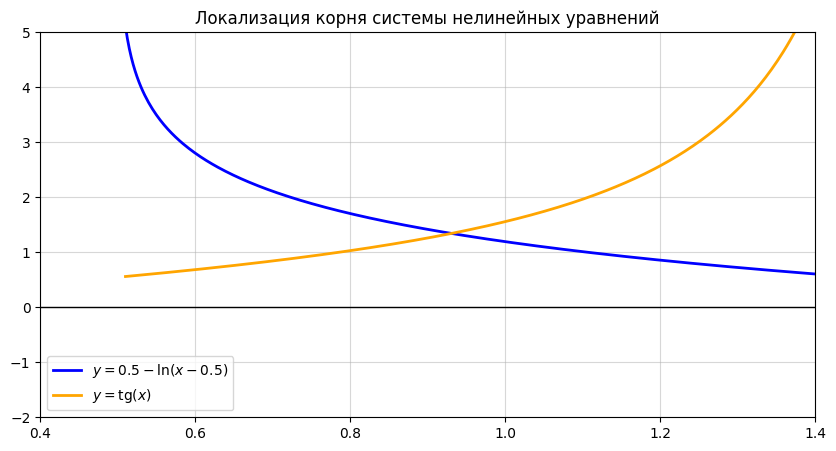

Из графика видно, что корень находится в окрестности $x = 0.9, y = 1.3$

In [5]:
plot.figure(figsize=(10, 5))
x_vals = np.linspace(0.51, 1.5, 400)
y1_vals = 0.5 - np.log(x_vals - 0.5)
y2_vals = np.tan(x_vals)

plot.plot(x_vals, y1_vals, label=r'$y = 0.5 - \ln(x - 0.5)$', color='blue', linewidth=2)
plot.plot(x_vals, y2_vals, label=r'$y = \mathrm{tg}(x)$', color='orange', linewidth=2)
plot.axhline(0, color='black', linewidth=1)
plot.axvline(0, color='black', linewidth=1)
plot.grid(True, alpha=0.5)
plot.xlim(0.4, 1.4)
plot.ylim(-2, 5)
plot.title("Локализация корня системы нелинейных уравнений")
plot.legend()
plot.show()

md("Из графика видно, что корень находится в окрестности $x = 0.9, y = 1.3$")

In [6]:
def F(v):
    x, y = v
    return np.array([
        x - np.exp(0.5 - y) - 0.5,
        y - np.tan(x)
    ])

def Jacobian(v):
    x, y = v
    return np.array([
        [1, np.exp(0.5 - y)],
        [-1 / (np.cos(x)**2), 1]
    ])

def newton_system(v0, eps=0.001):
    v = np.array(v0, dtype=float)
    iterations = 0
    while True:
        F_val = F(v)
        J_val = Jacobian(v)
        delta = np.linalg.solve(J_val, -F_val)
        v += delta
        iterations += 1
        if np.max(np.abs(delta)) < eps:
            return v, iterations

# В качестве начального приближения берем x=0.9, y=1.3 (найдено по графику)
x4, y4 = 0.9, 1.3
res4, iters4 = newton_system([x4, y4], eps=0.001)

md(f"Количество итераций: {iters4}")
md("Приближенное решение:")
md(f"$x = {res4[0]:.3f}$")
md(f"$y = {res4[1]:.3f}$")

Количество итераций: 3

Приближенное решение:

$x = 0.931$

$y = 1.343$

## 5. Проверка результатов

In [7]:
md("### Проверка Задачи 1 (Гаусс)")
res_np1 = np.linalg.solve(A1, b1)
for i, (xi, xi_np) in enumerate(zip(x1, res_np1)):
    md(f"$x_{i+1}$: полученное = {xi:.5f}, ожидаемое = {xi_np:.5f}")

md("### Проверка Задачи 2 (Итерации)")
res_np2 = np.linalg.solve(np.eye(4) - B2, c2)
for i, (xi, xi_np) in enumerate(zip(x2, res_np2)):
    md(f"$x_{i+1}$: полученное = {xi:.5f}, точное = {xi_np:.5f}")

md("### Проверка Задачи 3 (Обратная матрица)")
res_np3 = np.linalg.solve(A3, b3)
for i, (xi, xi_np) in enumerate(zip(x3, res_np3)):
    md(f"$x_{i+1}$: полученное = {xi:.5f}, точное = {xi_np:.5f}")

md("### Проверка Задачи 4 (Ньютон)")
import scipy.optimize as opt
res_np4 = opt.fsolve(F, [0.9, 1.3])
md(f"Полученное: x = {res4[0]:.5f}, y = {res4[1]:.5f}")
md(f"fsolve: x = {res_np4[0]:.5f}, y = {res_np4[1]:.5f}")

### Проверка Задачи 1 (Гаусс)

$x_1$: полученное = 3.47148, ожидаемое = 3.47148

$x_2$: полученное = 2.05416, ожидаемое = 2.05416

$x_3$: полученное = -2.11383, ожидаемое = -2.11383

$x_4$: полученное = -1.32762, ожидаемое = -1.32762

...

$x_2$: полученное = 1.00000, точное = 1.00000

$x_3$: полученное = 1.00000, точное = 1.00000

### Проверка Задачи 4 (Ньютон)

Полученное: x = 0.93060, y = 1.34257

fsolve: x = 0.93060, y = 1.34257